In [154]:
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
import scipy as sp
from sklearn.decomposition import PCA

import random
from collections import defaultdict

import torch
from torch import nn, optim
device = torch.accelerator.current_accelerator().type if torch.accelerator.is_available() else "cpu"
from torch.utils.data import Dataset, DataLoader
import torch.nn.functional as F
import torchvision
import torchvision.transforms as transforms

import sys
print(sys.executable)
import os
print(os.getcwd())

from pathlib import Path

/Users/owenyi/Desktop/Code_Projects/Python/ML_and_reinforcement/.venv/bin/python
/Users/owenyi/Desktop/Code_Projects/Python/ML_and_reinforcement/joint_embedding


In [99]:
DATASET_PATH = Path("../datasets/data")
assert DATASET_PATH.exists()

In [100]:
dataset = torchvision.datasets.MNIST(
    root=DATASET_PATH,
    download=True,
)


(np.float64(-0.5), np.float64(27.5), np.float64(27.5), np.float64(-0.5))

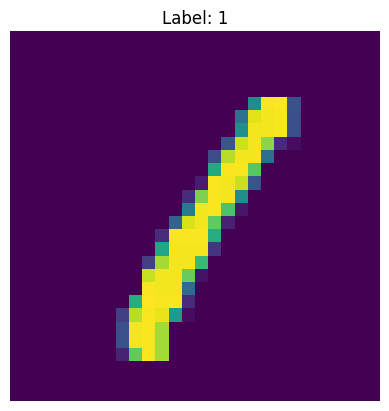

In [101]:
img, label = dataset[3]

# Display
plt.imshow(img)
plt.title(f"Label: {label}")
plt.axis('off')

Text(0.5, 1.0, 'Augmented')

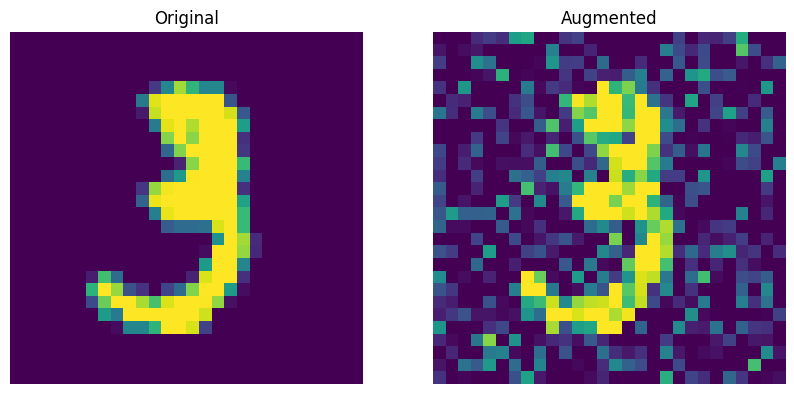

In [357]:
img_size = 224

class AddGaussianNoise:
    def __init__(self, mean=0.0, std=0.1, clamp=True):
        self.mean = mean
        self.std = std
        self.clamp = clamp  # keep values in valid range

    def __call__(self, img):
        """
        img: Tensor of shape (C, H, W), typically in [0, 1]
        """
        if not torch.is_tensor(img):
            raise TypeError("Input must be a torch Tensor")

        noise = torch.randn_like(img) * self.std + self.mean
        img = img + noise

        if self.clamp:
            img = torch.clamp(img, 0.0, 1.0)

        return img
    
strong_transform = transforms.Compose([
    transforms.ToTensor(),
    AddGaussianNoise(std = 0.3)
])

weak_transform = transforms.Compose([
    transforms.ToTensor(),
])

def tensor_to_numpy(img_tensor, mean=None, std=None):
    img = img_tensor.detach().cpu().float()
    if mean is not None and std is not None:
        for c in range(img.shape[0]):
            img[c] = img[c] * std[c] + mean[c]
    img = torch.clamp(img, 0.0, 1.0)
    img = img.permute(1, 2, 0)

    return img.numpy()

img, label = dataset[10]
fig, ax = plt.subplots(1, 2, figsize = (10, 5))
ax[0].imshow(tensor_to_numpy(weak_transform(img)))
ax[0].axis('off')
ax[0].set_title("Original")
ax[1].imshow(tensor_to_numpy(strong_transform(img)))
ax[1].axis('off')
ax[1].set_title("Augmented")

In [103]:
class MNIST(Dataset):
    def __init__(self, root):
        self.ds = torchvision.datasets.MNIST(root = root, download = False)

        self.aug_transform = transforms.Compose([
            transforms.ToTensor(),
            AddGaussianNoise(std = 0.25)
        ])
        self.orig_transform = transforms.ToTensor()

    def __len__(self):
        return len(self.ds)
    def __getitem__(self, idx):
        img, _ = self.ds[idx]

        aug = self.aug_transform(img)
        orig = self.orig_transform(img)

        return aug, orig


trainset = MNIST(root = DATASET_PATH)
trainloader = DataLoader(
    trainset,
    batch_size=64,
    shuffle=True,
    num_workers=0,
    drop_last=True
)
img_aug_example, img_orig_example = next(iter(trainloader))

This is the original SIGREG code from https://github.com/galilai-group/lejepa/blob/main/MINIMAL.md


```python
class SIGReg(torch.nn.Module):
    def __init__(self, knots=17):
        super().__init__()
        t = torch.linspace(0, 3, knots, dtype=torch.float32)
        dt = 3 / (knots - 1)
        weights = torch.full((knots,), 2 * dt, dtype=torch.float32)
        weights[[0, -1]] = dt
        window = torch.exp(-t.square() / 2.0)
        self.register_buffer("t", t)
        self.register_buffer("phi", window)
        self.register_buffer("weights", weights * window)

    def forward(self, proj):
        A = torch.randn(proj.size(-1), 256)
        A = A.div_(A.norm(p=2, dim=0))
        x_t = (proj @ A).unsqueeze(-1) * self.t
        err = (x_t.cos().mean(-3) - self.phi).square() + x_t.sin().mean(-3).square()
        statistic = (err @ self.weights) * proj.size(-2)
        return statistic.mean()
sigreg = SIGReg()
print(sigreg(img_aug))
```

Now the idea is simple but there are some tricks used in this implementation.
- E.g. Characteristic of a Distribution

Idea: We would like to enforce that our representation is distributed as a spherical gaussian. To do this, we grab a batch sample and check that sample looks gaussian. Checking goodness of fit for N-dimension distribution is hard. Therefore we project our batch onto random dimensions


In [104]:
def stub_model(x: torch.Tensor) -> torch.Tensor:
    """This stub model downprojects (B, D) -> (B, 2)"""
    x_flat = x.view(x.shape[0], -1)    
    return x_flat[:, :2]

emb = stub_model(img_aug_example)
print("emb.shape:", emb.shape)

emb.shape: torch.Size([64, 2])


In [105]:
A = torch.randn(emb.size(-1), 1)
A = A.div_(A.norm(p = 2, dim = 0))
print("A", A)

A tensor([[0.5127],
        [0.8586]])


In [106]:
x_t = (emb @ A).squeeze(-1)
print(x_t)

tensor([0.1536, 0.3755, 0.0585, 0.1588, 0.2659, 0.0086, 0.3206, 0.2485, 0.0511,
        0.1940, 0.3943, 0.1460, 0.4093, 0.5349, 0.0000, 0.3561, 0.2464, 0.2860,
        0.1761, 0.1056, 0.0000, 0.0000, 0.0000, 0.6485, 0.0478, 0.3517, 0.1294,
        0.3912, 0.1503, 0.1157, 0.0548, 0.1409, 0.1538, 0.0371, 0.0364, 0.0000,
        0.1829, 0.0957, 0.0000, 0.1535, 0.0000, 0.4343, 0.4227, 0.0636, 0.3105,
        0.1033, 0.0614, 0.0054, 0.0666, 0.0000, 0.1750, 0.0217, 0.1732, 0.3885,
        0.1377, 0.2170, 0.1188, 0.3767, 0.0000, 0.1165, 0.4003, 0.2536, 0.0651,
        0.0331])


In [107]:
x_t_sorted = np.sort(x_t)
x_grid = np.linspace(-4, 4, 500)
dx = x_grid[1] - x_grid[0]
cdf_emp = np.searchsorted(x_t_sorted, x_grid, side='right') / len(x_t_sorted)
cdf_theo = 0.5 * (1 + sp.special.erf((x_grid - 0) / (1 * np.sqrt(2))))

wasserstein_distance = np.sum(np.abs(cdf_emp - cdf_theo) * dx)
print("wasserstein_distance:", wasserstein_distance)

wasserstein_distance: 0.6855993369922693


But with search sorted, we can't really propagate gradients. We need a smoother approximation.

Another way to compute the empirical CDF at a point `x_s` is to count the proportion of points that are less than `x_s`. So we should have an indicator function that is 1 if x < x_s and 0 else. The soft version of that is a sigmoid. The CDF is simply 1/64 * sum of all these indicators (sigmoids) 

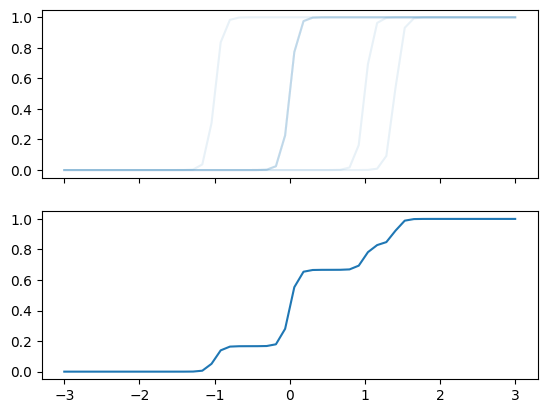

In [108]:
wasserstein_example_sample = np.array([1, 0, -1, 0, 0, 1.4])
example_eval_points = np.linspace(-3, 3, 50)
example_dx = example_eval_points[1] - example_eval_points[0]

fig, ax = plt.subplots(2, 1, sharex = True)
sigmoid = lambda z: 1 / (1 + np.exp(-z))
_k = 20.0

dist = 0
for example_x in wasserstein_example_sample:
    part = sigmoid(_k * (example_eval_points - example_x))
    dist += 1/len(wasserstein_example_sample) * part
    ax[0].plot(example_eval_points, part, alpha = 0.1, color = "tab:blue")
ax[1].plot(example_eval_points, dist)

In [109]:
x_min = -4 
x_max = 4
eval_points = 128
xs = torch.linspace(x_min, x_max, eval_points)
dx = xs[1] - xs[0]
diff = xs.view(-1, 1) - x_t.view(1, -1)
print(diff.shape)
k = 100.0
emp_cdf = torch.mean(torch.sigmoid(k * diff), dim=1)
theo_cdf = 0.5 * (1 + torch.erf((xs - 0) / (1 * np.sqrt(2))))

soft_wasserstein = torch.sum(torch.abs(emp_cdf - theo_cdf) * dx)
print("soft_wasserstein:", soft_wasserstein)

torch.Size([128, 64])
soft_wasserstein: tensor(0.6825)


/var/folders/qy/d4gqcbtd3mb8ywz_m0qm7g440000gn/T/ipykernel_31269/3040572852.py:4: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  ax[0].plot(A[0] * plot_t, A[1] * plot_t, color = "tab:red", label = "Random Direction")


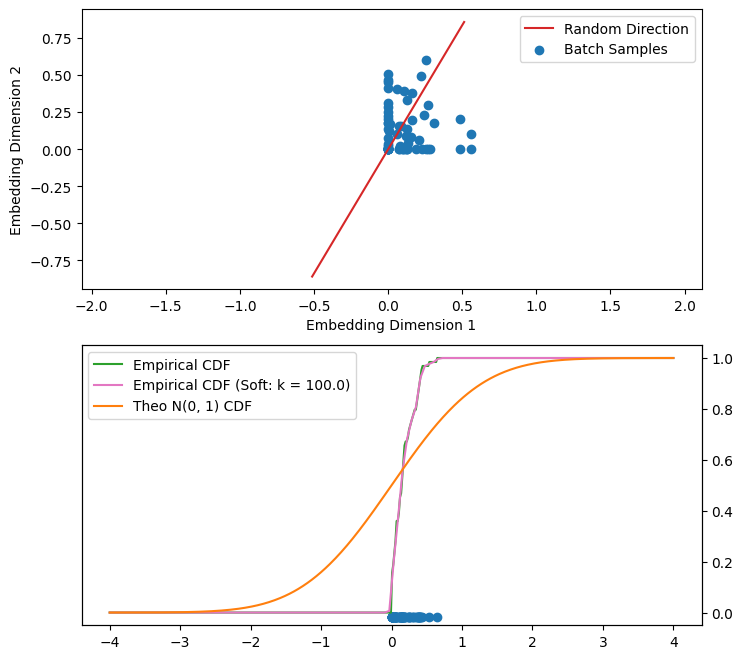

In [110]:
fig, ax = plt.subplots(2, 1, figsize = (8, 8))

plot_t = np.linspace(-1, 1)
ax[0].plot(A[0] * plot_t, A[1] * plot_t, color = "tab:red", label = "Random Direction")
ax[0].scatter(emb[:, 0], emb[:, 1], label = "Batch Samples")
ax[0].set_xlabel("Embedding Dimension 1")
ax[0].set_ylabel("Embedding Dimension 2")
ax[0].set_aspect('equal', adjustable = "datalim")
ax[0].legend()

ax[1].scatter(x_t, 0 * np.ones_like(x_t))
ax[1].set_ylim((0-0.03, 1))
ax[1].set_yticks([])
twinx = ax[1].twinx()

twinx.plot(x_grid, cdf_emp, color = "tab:green", label = "Empirical CDF")
twinx.plot(xs, emp_cdf, color = "tab:pink", label = f"Empirical CDF (Soft: k = {k})")
twinx.plot(x_grid, cdf_theo, color = "tab:orange", label = "Theo N(0, 1) CDF")
twinx.legend()

Training to minimise SIGREG loss

In [111]:
def soft_wasserstein(x_t, device = "cpu"):
    """
    x_t: (B, num_directions)
    """
    x_min = -5 
    x_max = 5
    eval_points = 128
    xs = torch.linspace(x_min, x_max, eval_points, device = device) # shape (eval_points)
    dx = xs[1] - xs[0]

    """
    xs.view(1, 1, -1) # shape (1, 1, eval_points)
    x_t.view(...) # shape (B, num_directions, 1)

    subtraction causes broadcasting in all dimensions
    """
    
    diff = xs.view(1, 1, -1) - x_t.view(x_t.shape[0], x_t.shape[1], 1) # shape (B, num_directions, eval_points)

    k = 100.0 
    emp_cdf = torch.mean(torch.sigmoid(k * diff), dim=0) # shape (num_directions, eval_points)
    theo_cdf = 0.5 * (1 + torch.erf((xs - 0) / (1 * np.sqrt(2)))) # shape (eval_points)
    wasserstein = torch.sum(torch.abs(emp_cdf - theo_cdf) * dx, axis = -1)
    return wasserstein

def SIGREG_loss(emb, device="cpu"):
    """
    emb: (B, D). B samples in batch. Each sample is an embedding within \mathbb{R}^D
    """
    A = torch.randn(emb.size(-1), 256, device = device) # 256 random directions. A: (D, 256)
    A = A.div_(A.norm(p = 2, dim = 0))
    
    x_t = (emb @ A) # x_t: squeeze of (B, D) @ (D, 256) -> (B, 256)
     
    wasserstein = soft_wasserstein(x_t, device)
    loss = wasserstein.mean()
    return loss

def stub_model_1(x: torch.Tensor) -> torch.Tensor:
    """This stub model downprojects (B, D) -> (B, 2)"""
    x_flat = x.view(x.shape[0], -1)    
    return x_flat[:, :32]

emb = stub_model_1(img_aug_example)
print("emb.shape:", emb.shape)
print(SIGREG_loss(emb))


emb.shape: torch.Size([64, 32])
tensor(0.6836)


In [112]:
class SimpleCNNEncoder(nn.Module):
    def __init__(self, output_dim=16):
        super().__init__()
        self.conv1 = nn.Conv2d(1, 32, 3, stride=1, padding=1)  # (B,32,28,28)
        self.conv2 = nn.Conv2d(32, 64, 3, stride=2, padding=1) # (B,64,14,14)
        self.conv3 = nn.Conv2d(64, 128, 3, stride=2, padding=1) # (B,128,7,7)
        self.fc = nn.Linear(128*7*7, output_dim)
    
    def forward(self, x):
        x = F.relu(self.conv1(x))  # (B,32,28,28)
        x = F.relu(self.conv2(x))  # (B,64,14,14)
        x = F.relu(self.conv3(x))  # (B,128,7,7)
        x = torch.flatten(x, 1)    # (B, 128*7*7)
        x = self.fc(x)             # (B, output_dim)
        return x

model = SimpleCNNEncoder()
model(img_aug_example)

tensor([[-0.0131, -0.0050, -0.0024,  ...,  0.0124, -0.0298,  0.0025],
        [-0.0383, -0.0057, -0.0173,  ...,  0.0172, -0.0225, -0.0015],
        [-0.0076, -0.0142, -0.0200,  ...,  0.0134, -0.0357, -0.0187],
        ...,
        [-0.0279, -0.0026, -0.0206,  ...,  0.0139, -0.0367,  0.0053],
        [-0.0239,  0.0043, -0.0244,  ...,  0.0203, -0.0283, -0.0043],
        [-0.0159, -0.0050, -0.0103,  ...,  0.0034, -0.0322, -0.0116]],
       grad_fn=<AddmmBackward0>)

In [113]:
trainset = MNIST(root = DATASET_PATH)
trainloader = DataLoader(
    trainset,
    batch_size=64,
    shuffle=True,
    num_workers=0,
    drop_last=True
)

model = SimpleCNNEncoder().to(device)
optimizer = torch.optim.Adam(
    model.parameters(),
    lr=1e-3,
    weight_decay=1e-4
)
model.train()
num_epochs = 3

In [114]:
for epoch in range(num_epochs):
    total_loss = 0.0
    for img_aug, img_orig in trainloader:
        img_aug = img_aug.to(device)
        img_orig = img_orig.to(device)

        z1 = model(img_aug)
        z2 = model(img_orig)

        loss = SIGREG_loss(z1, device)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
    print(f"Epoch {epoch+1}/{num_epochs} | Loss: {total_loss / len(trainloader):.4f}")


Epoch 1/3 | Loss: 0.2181
Epoch 2/3 | Loss: 0.1722
Epoch 3/3 | Loss: 0.1684


A tensor([[-0.2599],
        [-0.1494],
        [ 0.2996],
        [ 0.0774],
        [ 0.0329],
        [ 0.3179],
        [ 0.2958],
        [ 0.0058],
        [ 0.2963],
        [-0.3399],
        [ 0.0946],
        [ 0.1787],
        [-0.4886],
        [ 0.0007],
        [-0.1767],
        [ 0.3325]])


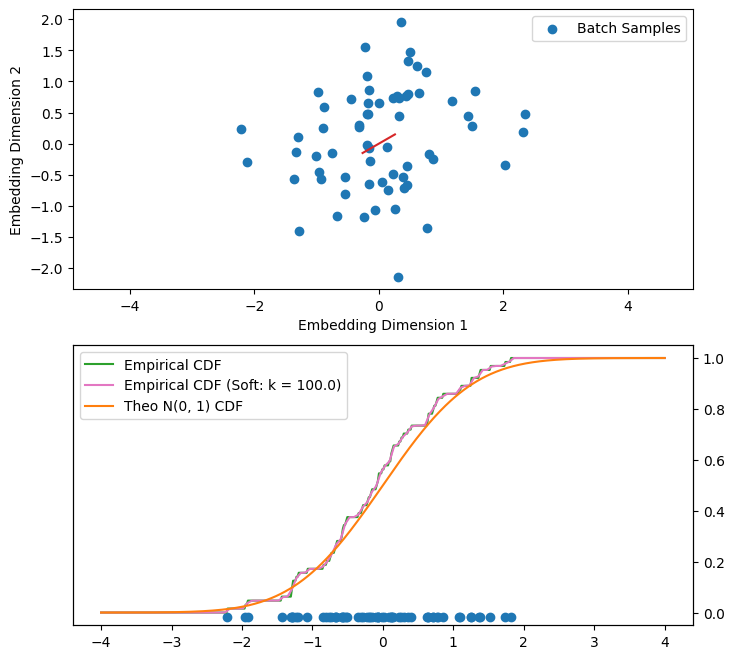

In [116]:
def visualise_guassianness_in_2D(emb):
    A = torch.randn(emb.size(-1), 1)
    A = A.div_(A.norm(p = 2, dim = 0))
    print("A", A)

    x_t = (emb @ A).squeeze(-1)
    x_t_sorted = torch.sort(x_t).values
    x_grid = torch.linspace(-4, 4, 500)
    dx = x_grid[1] - x_grid[0]
    cdf_emp_hard = torch.searchsorted(x_t_sorted, x_grid, right=True) / x_t_sorted.numel()

    x_grid = torch.linspace(-4, 4, 500)
    dx = x_grid[1] - x_grid[0]
    diff = xs.view(-1, 1) - x_t.view(1, -1)
    k = 100.0
    cdf_emp_soft = torch.mean(torch.sigmoid(k * diff), dim = 1)

    cdf_theo = 0.5 * (1 + torch.special.erf((x_grid - 0) / (1 * np.sqrt(2))))


    fig, ax = plt.subplots(2, 1, figsize = (8, 8))
    plot_At = torch.linspace(-1, 1, 100)
    ax[0].plot(A[0] * plot_At, A[1] * plot_At, color = "tab:red")
    ax[0].scatter(emb[:, 0], emb[:, 1], label = "Batch Samples")
    ax[0].set_xlabel("Embedding Dimension 1")
    ax[0].set_ylabel("Embedding Dimension 2")
    ax[0].set_aspect('equal', adjustable = "datalim")
    ax[0].legend()

    ax[1].scatter(x_t, 0 * np.ones_like(x_t))
    ax[1].set_ylim((0-0.03, 1))
    ax[1].set_yticks([])
    twinx = ax[1].twinx()

    twinx.plot(x_grid, cdf_emp_hard, color = "tab:green", label = "Empirical CDF")
    twinx.plot(xs, cdf_emp_soft, color = "tab:pink", label = f"Empirical CDF (Soft: k = {k})")
    twinx.plot(x_grid, cdf_theo, color = "tab:orange", label = "Theo N(0, 1) CDF")
    twinx.legend()

model.eval()
with torch.inference_mode():
    emb = model(img_aug).detach().cpu()
visualise_guassianness_in_2D(emb)

Visualise Embeddings

In [147]:
class MNIST_Label(Dataset):
    def __init__(self, root):
        self.ds = torchvision.datasets.MNIST(root = root, download = False)
        self.orig_transform = transforms.ToTensor()

    def __len__(self):
        return len(self.ds)

    def __getitem__(self, idx):
        img, label = self.ds[idx]

        orig = self.orig_transform(img)

        return orig, label

use_set = MNIST_Label(root = DATASET_PATH)
use_loader = DataLoader(use_set, batch_size=64, shuffle=False)

outputs_by_label = defaultdict(list)
model.eval()
with torch.inference_mode():
    for imgs, labels in use_loader:
        imgs = imgs.to(device)
        
        embs = model(imgs).detach().cpu()

        for emb, label in zip(embs, labels):
            outputs_by_label[label.item()].append(emb.cpu())

for key in outputs_by_label.keys():
    outputs_by_label[key] = torch.stack(outputs_by_label[key])

In [150]:
outputs_by_label[0]

tensor([[ 0.2592, -0.0892,  0.8936,  ..., -0.2464,  0.9440,  0.2656],
        [ 0.1026,  0.2814,  1.1676,  ...,  0.8747, -0.8323,  1.4148],
        [-0.1896,  0.8874,  0.7217,  ..., -0.2221, -0.9729,  0.2994],
        ...,
        [-0.9493, -2.1289, -0.0045,  ...,  0.3514, -1.0119,  1.0028],
        [-0.1374, -0.0187,  0.1154,  ...,  0.7816, -1.1642,  0.4789],
        [ 0.1102, -0.3016,  1.6307,  ...,  0.7392, -0.5665, -0.3251]])

In [148]:
first_two_dims_projector = lambda T: T[:, :2]

In [157]:
all_outputs = torch.cat(list(outputs_by_label.values()), dim=0)  # shape: [total_B, D]
all_outputs_np = all_outputs.numpy()
pca = PCA(n_components=2)
pca.fit(all_outputs_np)  # fit on all data

pca_projector = lambda T: pca.transform(T.numpy())

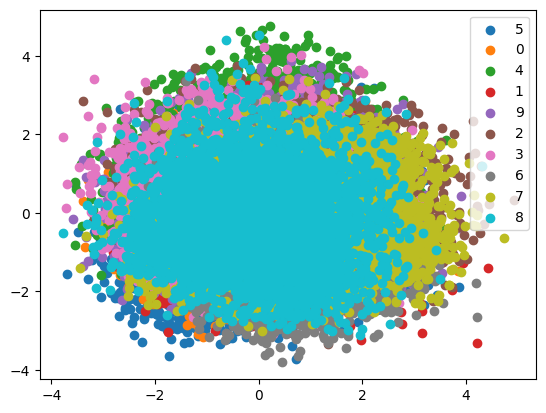

In [158]:
def visualise_embeddings_in_2D(embeddings: dict[int, torch.Tensor], projector):
    fig, ax = plt.subplots()

    for label, embs in embeddings.items():
        projs = projector(embs)

        x = projs[:, 0]
        y = projs[:, 1]
        ax.scatter(x, y, label = label)
    ax.legend()


visualise_embeddings_in_2D(outputs_by_label, pca_projector)

In [179]:
def predict_via_prototypes(encoder, prototypes: dict[int, torch.tensor], test: torch.tensor):
    similarity = {}

    test_output = encoder(test.to(device).unsqueeze(0)).cpu()

    for key, value in prototypes.items():
        similarity[key] = (0.5 * (test_output - value).square().mean()).item()

    return similarity # apply softmax etc.
prototypes = {
    k: v[0, :] for k, v in outputs_by_label.items()
}
test, label = use_set[69]
print(test.shape)

model.eval()
with torch.inference_mode():
    print(predict_via_prototypes(model, prototypes, test))

torch.Size([1, 28, 28])
{5: 1.3736482858657837, 0: 0.4741448163986206, 4: 0.6171252131462097, 1: 1.0453238487243652, 9: 0.671612560749054, 2: 1.3404765129089355, 3: 1.2604213953018188, 6: 0.6972753405570984, 7: 1.2345930337905884, 8: 0.8279052972793579}


Train Embeddings

In [ ]:
trainset = MNIST(root = DATASET_PATH)
trainloader = DataLoader(
    trainset,
    batch_size=64,
    shuffle=True,
    num_workers=0,
    drop_last=True
)

model = SimpleCNNEncoder().to(device)
optimizer = torch.optim.Adam(
    model.parameters(),
    lr=1e-3,
    weight_decay=1e-4
)
lamb = 0.5
model.train()
num_epochs = 10

In [359]:
for epoch in range(num_epochs):
    total_loss = 0.0
    total_invariance_loss = 0.0
    total_sigreg_loss = 0.0

    for img_aug, img_orig in trainloader:
        img_aug = img_aug.to(device)
        img_orig = img_orig.to(device)

        z1 = model(img_aug)
        z2 = model(img_orig)

        sigreg_loss = SIGREG_loss(z1, device)
        invariance_loss = 0.5 * (z1 - z2).square().mean()

        loss = sigreg_loss * lamb + invariance_loss * (1 - lamb)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        total_invariance_loss += invariance_loss.item()
        total_sigreg_loss += sigreg_loss.item()
    print(f"Epoch {epoch+1}/{num_epochs} | Loss: {total_loss / len(trainloader):.4f} | inv Loss: {total_invariance_loss / len(trainloader):.4f} | sigreg Loss: {total_sigreg_loss/ len(trainloader):.4f}")


Epoch 1/10 | Loss: 0.1208 | inv Loss: 0.0081 | sigreg Loss: 0.2334
Epoch 2/10 | Loss: 0.0930 | inv Loss: 0.0081 | sigreg Loss: 0.1778
Epoch 3/10 | Loss: 0.0890 | inv Loss: 0.0077 | sigreg Loss: 0.1704
Epoch 4/10 | Loss: 0.0885 | inv Loss: 0.0073 | sigreg Loss: 0.1697
Epoch 5/10 | Loss: 0.0875 | inv Loss: 0.0072 | sigreg Loss: 0.1678
Epoch 6/10 | Loss: 0.0874 | inv Loss: 0.0070 | sigreg Loss: 0.1679
Epoch 7/10 | Loss: 0.0872 | inv Loss: 0.0069 | sigreg Loss: 0.1675
Epoch 8/10 | Loss: 0.0866 | inv Loss: 0.0068 | sigreg Loss: 0.1663
Epoch 9/10 | Loss: 0.0869 | inv Loss: 0.0068 | sigreg Loss: 0.1671
Epoch 10/10 | Loss: 0.0859 | inv Loss: 0.0068 | sigreg Loss: 0.1649


A tensor([[-0.1318],
        [-0.1827],
        [ 0.3450],
        [ 0.0866],
        [-0.0458],
        [ 0.2873],
        [-0.2278],
        [ 0.3743],
        [-0.4902],
        [-0.4139],
        [ 0.1944],
        [-0.2013],
        [ 0.0439],
        [-0.1710],
        [ 0.0735],
        [-0.1399]])


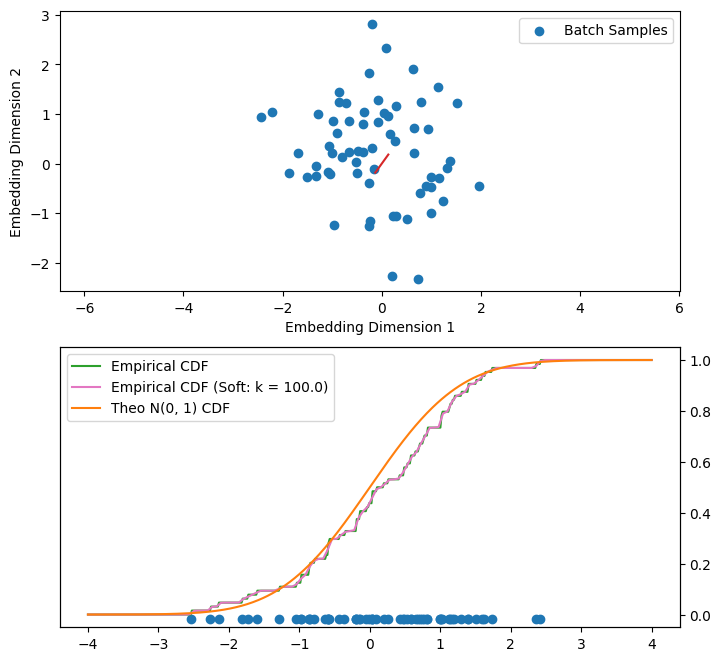

In [362]:
img_aug, img_orig = next(iter(trainloader))
img_aug = img_aug.to(device)
emb = model(img_aug).detach().cpu()
visualise_guassianness_in_2D(emb)

In [363]:
outputs_by_label = defaultdict(list)
model.eval()
with torch.inference_mode():
    for imgs, labels in use_loader:
        imgs = imgs.to(device)
        
        embs = model(imgs).detach().cpu()

        for emb, label in zip(embs, labels):
            outputs_by_label[label.item()].append(emb.cpu())

for key in outputs_by_label.keys():
    outputs_by_label[key] = torch.stack(outputs_by_label[key])


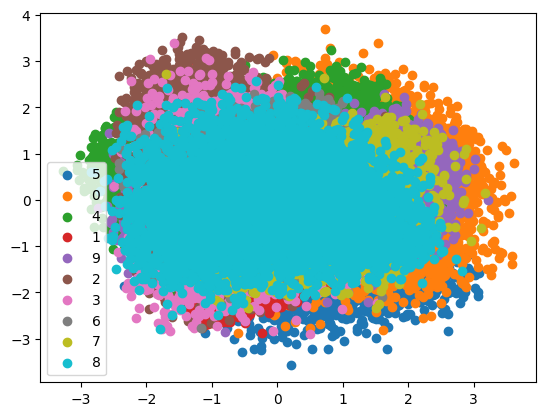

In [364]:
all_outputs = torch.cat(list(outputs_by_label.values()), dim=0)  # shape: [total_B, D]
all_outputs_np = all_outputs.numpy()

pca = PCA(n_components=2)
pca.fit(all_outputs_np)  # fit on all data

pca_projector = lambda T: pca.transform(T.numpy())
visualise_embeddings_in_2D(outputs_by_label, pca_projector)

# visualise_embeddings_in_2D(outputs_by_label, first_two_dims_projector)

In [306]:
outputs_by_label[0].mean(dim = 0)

tensor([-0.2335,  0.0736, -0.0141,  0.4759, -0.6632,  0.1334,  0.2028,  0.4159,
         0.1956, -0.6768, -0.3462, -0.5468, -0.3112, -0.7405, -0.0210, -0.2281,
        -0.3253,  0.9407,  0.2574,  0.1054, -0.4981, -0.1438, -0.3780, -0.2564,
         0.1513,  0.3969,  0.0393, -0.0680, -0.1810,  0.3752,  0.7564, -0.4326,
         0.5763, -0.5991,  0.3987,  0.1679,  0.1466,  0.0860,  0.5426,  0.4638,
         0.4897,  0.3409,  0.5561,  0.0293, -1.0441,  0.6829, -0.1153,  0.0798,
        -0.2472,  0.4731, -0.1559,  0.0348,  0.2652,  0.5069,  0.2063,  0.0085,
         0.0411, -1.6102, -0.0565,  0.4675,  0.7177,  0.5127, -0.0135,  0.5990])

37808 8


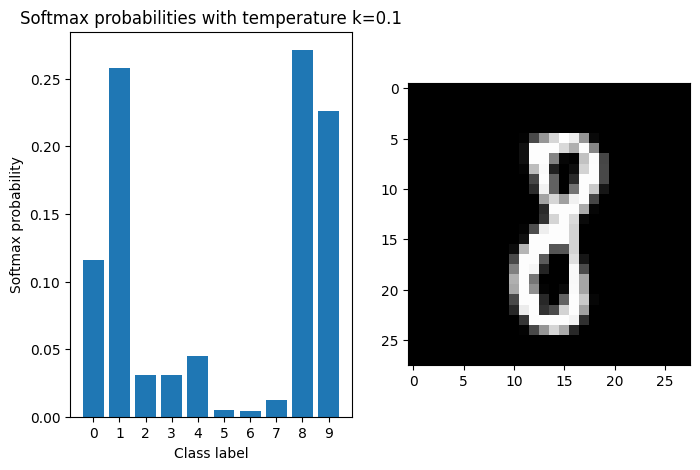

In [382]:
# random.seed(3)
idx = random.randint(0, len(use_set) - 1)
test, label = use_set[idx]

prototypes = {k: v[0, :] for k, v in outputs_by_label.items()} # Use the first labelled example
# prototypes = {k: v.mean(dim = 0) for k, v in outputs_by_label.items()} # Use all labelled examples

model.eval()
with torch.inference_mode():
    similarities = predict_via_prototypes(model, prototypes, test)

print(idx, label)

k = 0.1
keys_sorted = sorted(similarities.keys())
values_sorted = torch.tensor([similarities[k] for k in keys_sorted])
probs = torch.softmax(-values_sorted / k, dim=0)

fig, ax = plt.subplots(1, 2, figsize = (8, 5))
ax[0].bar(keys_sorted, probs.numpy())
ax[0].set_xlabel("Class label")
ax[0].set_ylabel("Softmax probability")
ax[0].set_title(f"Softmax probabilities with temperature k={k}")
ax[0].set_xticks(keys_sorted)  # ensure x-axis labels are 0-9
ax[1].imshow(test.squeeze(), cmap='gray')  # remove channel dim
ax[1].set_aspect("equal")

In [386]:
def classify_by_prototypes(outputs_by_label: dict[int, torch.Tensor], prototypes: dict[int, torch.Tensor]):
    """
    outputs_by_label: dict[label, tensor of shape [B_label, D]]
    prototypes: dict[class_label, tensor of shape [D]]
    returns: dict[label, tensor of predicted class indices for each embedding]
    """

    # Move prototypes to device and stack them for vectorized computation
    proto_keys = sorted(prototypes.keys())  # ensure consistent ordering
    proto_tensor = torch.stack([prototypes[k].to(device) for k in proto_keys])  # shape: [10, D]
    
    pred_dict = {}
    
    for label, embeddings in outputs_by_label.items():
        embeddings = embeddings.to(device)  # [B_label, D]
        
        # Compute squared distances to all prototypes: (x - p)^2 / 2
        # embeddings: [B, D], proto_tensor: [10, D]
        # use broadcasting: [B, 10, D]
        diff = embeddings.unsqueeze(1) - proto_tensor.unsqueeze(0)  # [B, 10, D]
        dist = 0.5 * (diff ** 2).mean(dim=2)  # [B, 10] mean over feature dimension
        
        # Pick argmin along prototype dimension
        preds = dist.argmin(dim=1)  # [B], indices correspond to proto_keys
        # Map indices back to actual class labels
        pred_classes = torch.tensor([proto_keys[i] for i in preds], device=device)
        
        pred_dict[label] = pred_classes.cpu()
    
    return pred_dict
prototypes = {k: v[0, :16] for k, v in outputs_by_label.items()} # use 16 labelled examples for each class
classification = classify_by_prototypes(outputs_by_label, prototypes)


Confusion matrix:
 [[4296   91  161    2  203   26  103   58  391  592]
 [   4 2485   29    7 1024   51  592   46  321 2183]
 [ 272  582 2803  318  470   61  269  119  704  360]
 [ 642  149  524 2447 1130  127  104  125  397  486]
 [  28  252  147   89 2092    0  217  483  226 2308]
 [ 213  230  506  415  668  911  410  130 1181  757]
 [ 238  699  366    2  399   88 3806   52  218   50]
 [ 177  179  131   10  202   53   10 3043   80 2380]
 [  67  474  110  264  892   68  151   73 3132  620]
 [  77   23   70  148 1154    4   36 1033  220 3184]]


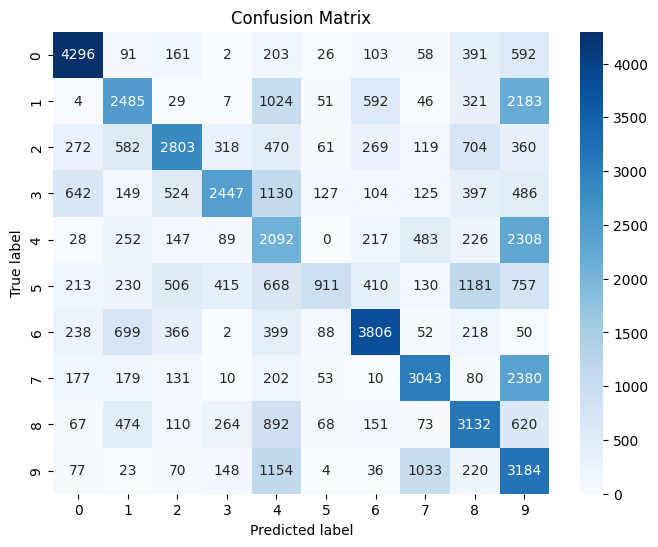

In [389]:
import seaborn as sns
from sklearn.metrics import confusion_matrix

# pred_dict: dictionary of predicted labels
# Make sure each tensor is 1D
true_labels = []
pred_labels = []

for true_label, preds in classification.items():
    # Flatten in case it's [B, 1] or similar
    preds_flat = preds.view(-1).tolist()  # flatten to 1D
    true_labels.extend([true_label] * len(preds_flat))
    pred_labels.extend(preds_flat)

# Convert to NumPy arrays
true_labels = np.array(true_labels)
pred_labels = np.array(pred_labels)

# Compute confusion matrix
cm = confusion_matrix(true_labels, pred_labels, labels=range(10))
print("Confusion matrix:\n", cm)

# Plot
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=range(10), yticklabels=range(10))
plt.xlabel("Predicted label")
plt.ylabel("True label")
plt.title("Confusion Matrix")
plt.show()

In [391]:
correct = np.trace(cm)
total = cm.sum()
accuracy = correct / total
print(f"Accuracy: {accuracy:.4f}")

Accuracy: 0.4700
